In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("ecommerce_customer_churn_dataset.csv")
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


## LETS SOLVE FOR CHURN

In [3]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [4]:
df.drop(['Wishlist_Items', 'Email_Open_Rate', 'Returns_Rate', 'Customer_Service_Calls',
         'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Payment_Method_Diversity', 'Signup_Quarter'], axis=1, inplace=True)

In [5]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_23916\1698716155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [6]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Mobile_App_Usage,Lifetime_Value,Credit_Balance,Churned
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,9.0,94.72,34.0,46.40,20.8,953.33,2278.0,0
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,19.5,82.45,71.0,57.96,23.3,1067.47,3028.0,0
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,9.1,165.52,11.0,12.24,8.8,1289.75,2317.0,0
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,15.0,147.33,47.0,44.10,31.0,2340.92,2674.0,0
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,32.5,141.30,73.0,25.20,50.4,3041.29,5354.0,0


In [7]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Mobile_App_Usage,Lifetime_Value,Credit_Balance,Churned
count,50000.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,50000.000000,50000.000000,47000.000000,46500.000000,45000.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,13.111576,123.117330,29.792872,41.997485,19.371607,1440.626292,1966.233258,0.289000
std,11.535608,2.059105,7.810657,10.871013,3.778220,16.282723,7.017312,175.569714,29.695062,21.373642,9.419252,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,-13.000000,26.380000,0.000000,0.240000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.400000,6.000000,19.700000,6.000000,46.400000,8.000000,87.050000,9.000000,25.300000,12.500000,789.817500,1049.000000,0.000000
50%,37.802968,2.500000,11.000000,26.800000,8.400000,58.100000,12.000000,112.970000,21.000000,40.200000,18.600000,1243.415000,1896.000000,0.000000
75%,45.000000,4.000000,17.000000,34.700000,11.200000,68.700000,17.000000,144.440000,41.000000,57.000000,25.500000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,128.700000,9666.379178,287.000000,116.640000,61.900000,8987.240000,7197.000000,1.000000


<Axes: >

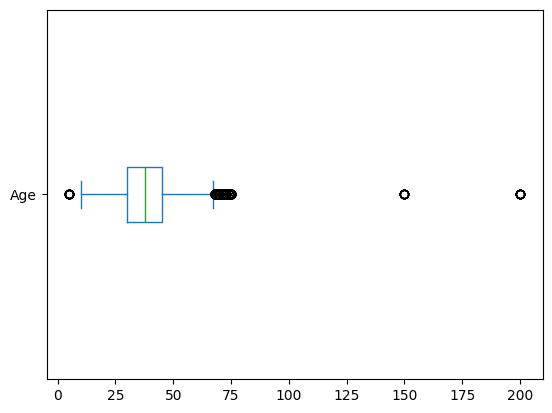

In [8]:
df['Age'].plot.box(vert=False)

<Axes: >

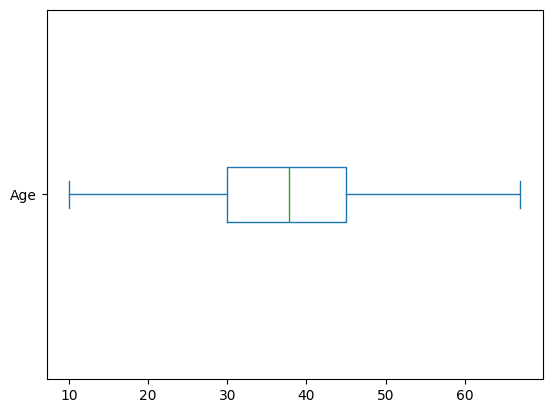

In [9]:
#Removing outliers
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3-Q1

df = df[(df['Age'] >= Q1-1.5*IQR) & (df['Age'] <= Q3+1.5*IQR)]

df['Age'].plot.box(vert=False)

In [10]:
df = df.reset_index(drop=True)
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Mobile_App_Usage,Lifetime_Value,Credit_Balance,Churned
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,9.0,94.72,34.0,46.40,20.8,953.33,2278.0,0
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,19.5,82.45,71.0,57.96,23.3,1067.47,3028.0,0
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,9.1,165.52,11.0,12.24,8.8,1289.75,2317.0,0
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,15.0,147.33,47.0,44.10,31.0,2340.92,2674.0,0
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,32.5,141.30,73.0,25.20,50.4,3041.29,5354.0,0


In [11]:
df=df.dropna().reset_index(drop=True)
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Mobile_App_Usage,Lifetime_Value,Credit_Balance,Churned
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,9.0,94.72,34.0,46.40,20.8,953.33,2278.0,0
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,19.5,82.45,71.0,57.96,23.3,1067.47,3028.0,0
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,9.1,165.52,11.0,12.24,8.8,1289.75,2317.0,0
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,15.0,147.33,47.0,44.10,31.0,2340.92,2674.0,0
4,35.0,Male,Japan,Tokyo,3.5,6.0,21.9,6.9,74.4,12.0,190.97,29.0,60.20,11.2,1995.43,2418.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30439,56.0,Female,Canada,Calgary,2.0,14.0,35.5,8.9,52.9,14.0,121.63,43.0,26.30,18.3,1581.65,2732.0,0
30440,18.0,Female,France,Lyon,4.8,8.0,21.0,8.4,69.5,16.0,51.86,45.0,25.60,14.6,813.11,3565.0,1
30441,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,13.0,156.76,18.0,62.70,25.2,2365.98,3499.0,0
30442,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,15.0,103.31,48.0,66.30,12.1,1293.60,3154.0,0


In [12]:
df['Gender'].value_counts()

Gender
Female    15430
Male      14471
Other       543
Name: count, dtype: int64

In [13]:
gencoun = df.groupby(['Country','Gender']).size().reset_index()
gencoun = gencoun.rename(columns={0:"Count"})
gencoun

,Country,Gender,Count
0,Australia,Female,1253
1,Australia,Male,1189
2,Australia,Other,43
3,Canada,Female,1806
4,Canada,Male,1738
5,Canada,Other,68
6,France,Female,1278
7,France,Male,1178
8,France,Other,50
9,Germany,Female,1511


In [14]:
import matplotlib.pyplot as  plt
import seaborn as sns

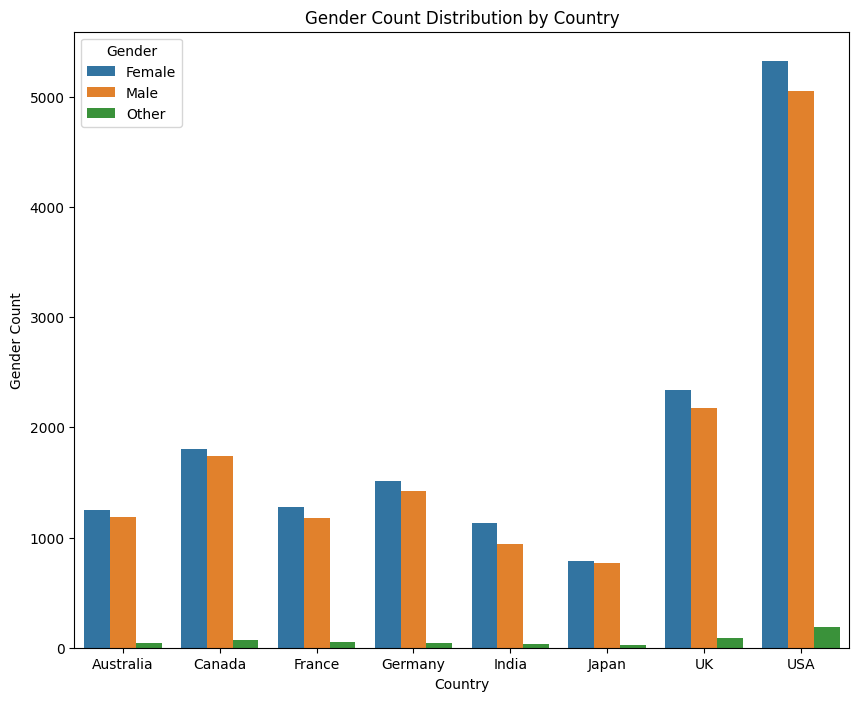

In [15]:
plt.figure(figsize=(10, 8))
sns.barplot(data=gencoun, x='Country', y='Count', hue='Gender')
plt.title('Gender Count Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Gender Count')
plt.show()

In [16]:
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Mobile_App_Usage,Lifetime_Value,Credit_Balance,Churned
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,9.0,94.72,34.0,46.40,20.8,953.33,2278.0,0
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,19.5,82.45,71.0,57.96,23.3,1067.47,3028.0,0
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,9.1,165.52,11.0,12.24,8.8,1289.75,2317.0,0
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,15.0,147.33,47.0,44.10,31.0,2340.92,2674.0,0
4,35.0,Male,Japan,Tokyo,3.5,6.0,21.9,6.9,74.4,12.0,190.97,29.0,60.20,11.2,1995.43,2418.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30439,56.0,Female,Canada,Calgary,2.0,14.0,35.5,8.9,52.9,14.0,121.63,43.0,26.30,18.3,1581.65,2732.0,0
30440,18.0,Female,France,Lyon,4.8,8.0,21.0,8.4,69.5,16.0,51.86,45.0,25.60,14.6,813.11,3565.0,1
30441,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,13.0,156.76,18.0,62.70,25.2,2365.98,3499.0,0
30442,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,15.0,103.31,48.0,66.30,12.1,1293.60,3154.0,0


In [17]:
df['Total_Purchases'] = df['Total_Purchases'].astype('int')

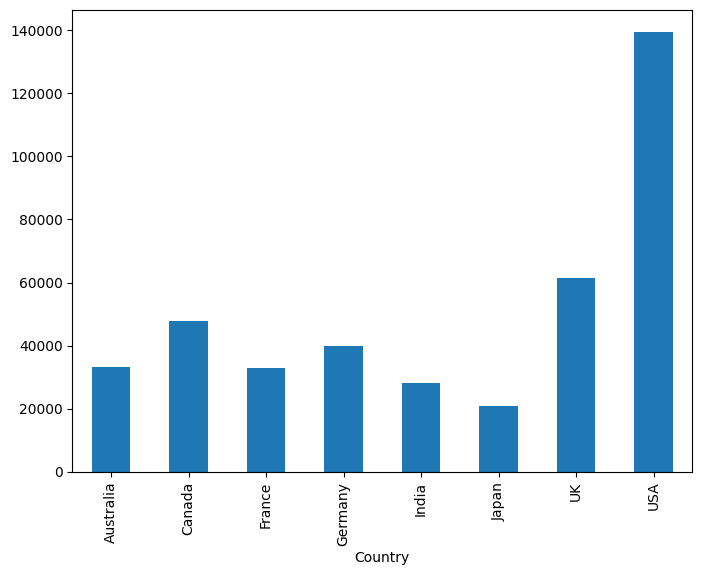

In [18]:
counuse = df.groupby('Country')['Total_Purchases'].sum()

plt.figure(figsize=(8, 6))
counuse.plot(kind='bar')
plt.show()

In [19]:
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Mobile_App_Usage,Lifetime_Value,Credit_Balance,Churned
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,9,94.72,34.0,46.40,20.8,953.33,2278.0,0
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,19,82.45,71.0,57.96,23.3,1067.47,3028.0,0
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,9,165.52,11.0,12.24,8.8,1289.75,2317.0,0
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,15,147.33,47.0,44.10,31.0,2340.92,2674.0,0
4,35.0,Male,Japan,Tokyo,3.5,6.0,21.9,6.9,74.4,12,190.97,29.0,60.20,11.2,1995.43,2418.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30439,56.0,Female,Canada,Calgary,2.0,14.0,35.5,8.9,52.9,14,121.63,43.0,26.30,18.3,1581.65,2732.0,0
30440,18.0,Female,France,Lyon,4.8,8.0,21.0,8.4,69.5,16,51.86,45.0,25.60,14.6,813.11,3565.0,1
30441,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,13,156.76,18.0,62.70,25.2,2365.98,3499.0,0
30442,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,15,103.31,48.0,66.30,12.1,1293.60,3154.0,0


In [20]:
df.corr(numeric_only=True)

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Mobile_App_Usage,Lifetime_Value,Credit_Balance,Churned
Age,1.000000,-0.006729,0.004240,0.004845,0.010046,-0.001705,0.005035,-0.009484,-0.002261,-0.002476,0.007235,0.007315,0.000159,-0.119367
Membership_Years,-0.006729,1.000000,0.001640,0.005741,0.006878,-0.000993,-0.019547,0.001248,-0.002472,0.000225,0.002258,0.002315,0.004493,-0.003786
Login_Frequency,0.004240,0.001640,1.000000,0.704161,0.676456,-0.625144,0.607416,0.004233,0.004487,-0.004836,0.674940,0.493960,0.510187,-0.192255
Session_Duration_Avg,0.004845,0.005741,0.704161,1.000000,0.756176,-0.699839,0.679828,-0.002587,-0.000984,0.001813,0.756031,0.549943,0.563761,-0.223319
Pages_Per_Session,0.010046,0.006878,0.676456,0.756176,1.000000,-0.668348,0.645943,0.001298,-0.004584,0.001064,0.725910,0.527733,0.544693,-0.216045
Cart_Abandonment_Rate,-0.001705,-0.000993,-0.625144,-0.699839,-0.668348,1.000000,-0.595221,0.001741,-0.000678,-0.002114,-0.667370,-0.484378,-0.497072,0.265247
Total_Purchases,0.005035,-0.019547,0.607416,0.679828,0.645943,-0.595221,1.000000,0.000852,0.012668,0.034392,0.644743,0.639645,0.483320,-0.153761
Average_Order_Value,-0.009484,0.001248,0.004233,-0.002587,0.001298,0.001741,0.000852,1.000000,-0.000914,-0.004865,-0.004180,0.149822,0.005790,0.045572
Days_Since_Last_Purchase,-0.002261,-0.002472,0.004487,-0.000984,-0.004584,-0.000678,0.012668,-0.000914,1.000000,-0.001688,-0.000492,0.002551,0.000386,0.148696
Discount_Usage_Rate,-0.002476,0.000225,-0.004836,0.001813,0.001064,-0.002114,0.034392,-0.004865,-0.001688,1.000000,-0.000606,-0.003082,-0.005202,-0.081957


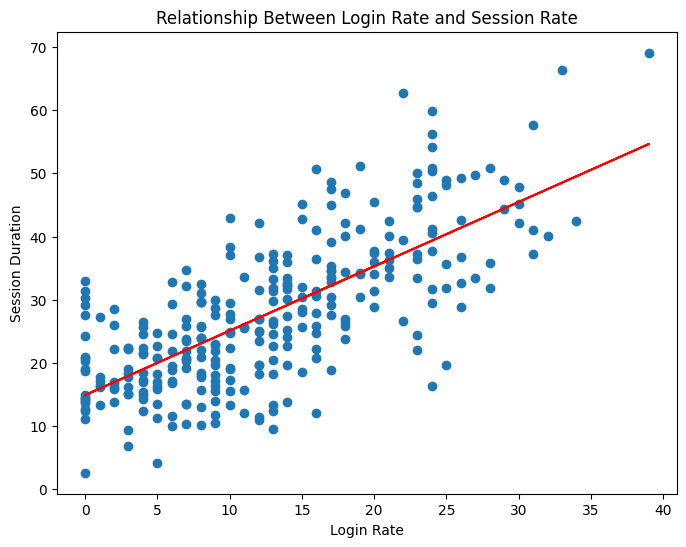

In [21]:
x = df['Login_Frequency'][:300]
y = df['Session_Duration_Avg'][:300]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 6))
plt.scatter(x, y)
plt.plot(x, m*x + b, color='red')
plt.title("Relationship Between Login Rate and Session Rate")
plt.xlabel("Login Rate")
plt.ylabel("Session Duration")
plt.show()

In [22]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True)

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Mobile_App_Usage,Lifetime_Value,Credit_Balance,Churned
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,9,94.72,34.0,46.40,20.8,953.33,2278.0,0
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,19,82.45,71.0,57.96,23.3,1067.47,3028.0,0
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,9,165.52,11.0,12.24,8.8,1289.75,2317.0,0
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,15,147.33,47.0,44.10,31.0,2340.92,2674.0,0
4,35.0,Male,Japan,Tokyo,3.5,6.0,21.9,6.9,74.4,12,190.97,29.0,60.20,11.2,1995.43,2418.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30439,56.0,Female,Canada,Calgary,2.0,14.0,35.5,8.9,52.9,14,121.63,43.0,26.30,18.3,1581.65,2732.0,0
30440,18.0,Female,France,Lyon,4.8,8.0,21.0,8.4,69.5,16,51.86,45.0,25.60,14.6,813.11,3565.0,1
30441,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,13,156.76,18.0,62.70,25.2,2365.98,3499.0,0
30442,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,15,103.31,48.0,66.30,12.1,1293.60,3154.0,0


In [23]:
from collections import Counter

count = Counter(df['Churned'])
count

Counter({0: 21906, 1: 8538})

In [24]:
df.select_dtypes(include='number').columns

Index(['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg',
       'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Mobile_App_Usage', 'Lifetime_Value',
       'Credit_Balance', 'Churned'],
      dtype='object')

In [25]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [26]:
X = df.drop("Churned", axis=1)
y = df['Churned']

In [27]:
cat_cols = []

for col in X.columns:
    if X[col].dtype == 'object':
        cat_cols.append(col)

In [28]:
num_cols = []

for col in X.columns:
    if col not in cat_cols:
        num_cols.append(col)

In [29]:
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(), cat_cols),
        ('num', StandardScaler(), num_cols)
    ])

transformed_data = preprocessor.fit_transform(X)
cat_col_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)

all_col_names = list(cat_col_names) + num_cols
X = pd.DataFrame(transformed_data.toarray(), columns=all_col_names)
X.head()

,Gender_Female,Gender_Male,Gender_Other,Country_Australia,Country_Canada,Country_France,Country_Germany,Country_India,Country_Japan,Country_UK,...,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Mobile_App_Usage,Lifetime_Value,Credit_Balance
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.030692,-0.772553,-0.330214,-0.626229,-0.161665,0.144359,0.212295,0.101003,-0.566914,0.213096
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.374883,0.361199,-1.125180,0.838354,-0.232813,1.397184,0.754514,0.365373,-0.442331,0.822276
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.269548,-1.932672,0.920778,-0.626229,0.248869,-0.634423,-1.389972,-1.167970,-0.199713,0.244773
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.979852,1.547684,-0.878679,0.252521,0.143394,0.584541,0.104414,1.179631,0.947633,0.534743
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.535964,-0.535256,1.136467,-0.186854,0.396440,-0.024941,0.859581,-0.914175,0.570532,0.326809


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ros = RandomOverSampler()

X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

X_train, X_test, y_train, y_test = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42)

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
model.score(X_train, y_train), model.score(X_test, y_test)

(1.0, 0.9217366466723793)

In [34]:
model.score(X_test, y_test)

0.9217366466723793

In [35]:
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, ConfusionMatrixDisplay, classification_report

In [37]:
acc = accuracy_score(y_test, y_pred)
acc

0.9217366466723793

In [38]:
cla = classification_report(y_test, y_pred)
print(cla)

              precision    recall  f1-score   support

           0       0.95      0.89      0.92      3516
           1       0.90      0.95      0.92      3486

    accuracy                           0.92      7002
   macro avg       0.92      0.92      0.92      7002
weighted avg       0.92      0.92      0.92      7002



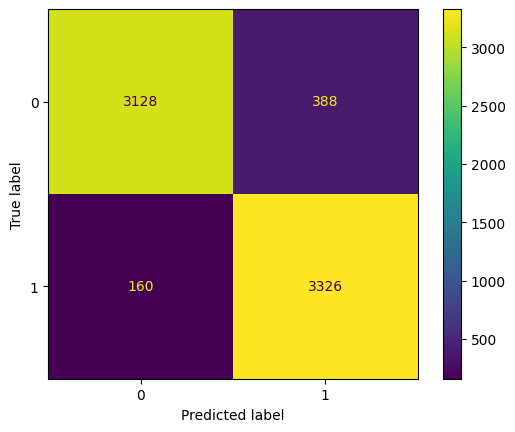

In [39]:
conf = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
conf

In [40]:
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance

,feature,importance
62,Lifetime_Value,0.109886
56,Cart_Abandonment_Rate,0.101949
51,Age,0.088182
60,Discount_Usage_Rate,0.074529
59,Days_Since_Last_Purchase,0.068947
...,...,...
40,City_Osaka,0.001124
46,City_Tokyo,0.001048
50,City_Yokohama,0.001047
37,City_Nagoya,0.001039


## FEATURE IMPORTANCE

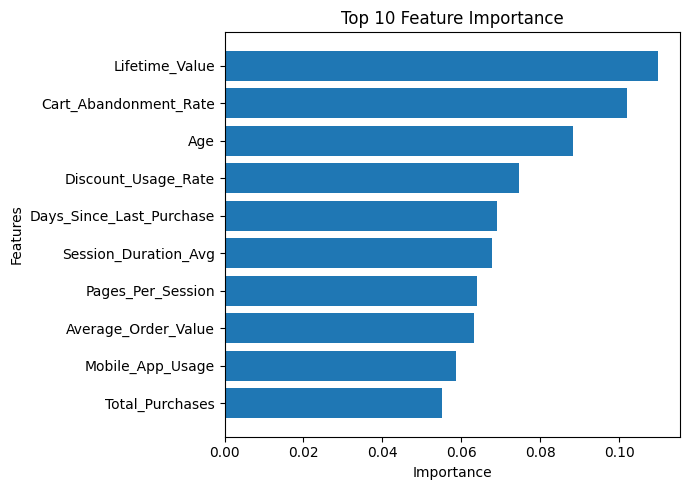

In [41]:
plt.figure(figsize=(7, 5))
plt.barh(
    feature_importance['feature'][:10],
    feature_importance['importance'][:10]
)
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Explanation
Feature importance shows how each model feature adds to the model prediction or decision. feature importance helps you see which features “drive” the model and which are less relevant, guiding interpretability, feature selection, and trust in the model’s outputs.


### According to the chart above;
1. Lifetime_Value: The strongest predictor. Customers with higher lifetime value behave differently from those with lower value
2. Cart_Abandonment_Rate: Critical behavioral signal about purchase intent and friction points
3. Age: Demographic factor showing different patterns across age groups
4. Discount_Usage_Rate: How price-sensitive customers are
5. Session_Duration_Avg: Engagement level indicator

The remaining features (Days_Since_Last_Purchase, Average_Order_Value, Mobile_App_Usage, Pages_Per_Session, Total_Purchases) all contribute but with less impact.

### How This Helps Your Business Decisions
Immediate Actions:

1. Focus retention efforts on high lifetime value customers - they're your most predictable segment
2. Reduce cart abandonment - it's the second strongest signal, so optimize checkout, send recovery emails, or address friction points
3. Age-based segmentation - tailor messaging and offers differently across age groups
4. Discount strategy - understand that discount dependency is a key behavioral pattern

### Strategic Insights:

You now know where to allocate resources - fixing cart abandonment will likely have more impact than increasing pages per session
You can build targeted interventions for each important feature rather than generic campaigns
This model tells you which customer signals to monitor most closely in real-time

This is essentially your roadmap for prioritizing business improvements based on what actually drives customer behavior.




In [42]:
## Saving the model and it components

import joblib

joblib.dump(preprocessor, 'col_encoder.pkl')
joblib.dump(model, 'model_cus.pkl')

['model_cus.pkl']

# USING PYTORCH

In [43]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [44]:
# turn the data to tensors
X_train_tensor = torch.FloatTensor(X_train.values)
X_test_tensor = torch.FloatTensor(X_test.values)

y_train_tensor = torch.LongTensor(y_train.values)
y_test_tensor = torch.LongTensor(y_test.values)

In [45]:
# Load dataset in batch
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [46]:
n_feat = X_train.shape[1]

In [47]:
class Churn(nn.Module):
    def __init__(self, n_feat, hidden1, hidden2, hidden3, out):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(n_feat, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, hidden3),
            nn.ReLU(),
            nn.Linear(hidden3, out)
        )
    def forward(self, X):
        return self.model(X)

In [48]:
torch.manual_seed(42)
model = Churn(n_feat, 70, 50, 40, 2)
epochs = 50
xentropy = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.004)

In [49]:
def train(model, optimizer, criterion, trainloader, epochs):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in trainloader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_loss = total_loss / len(trainloader)
        print(f'Epoch {epoch+1} / {epochs}, Loss: {mean_loss:.4f}')

In [50]:
train(model, optimizer, xentropy, train_loader, epochs)

Epoch 1 / 50, Loss: 0.5060
Epoch 2 / 50, Loss: 0.4656
Epoch 3 / 50, Loss: 0.4482
Epoch 4 / 50, Loss: 0.4337
Epoch 5 / 50, Loss: 0.4172
Epoch 6 / 50, Loss: 0.4017
Epoch 7 / 50, Loss: 0.3853
Epoch 8 / 50, Loss: 0.3753
Epoch 9 / 50, Loss: 0.3591
Epoch 10 / 50, Loss: 0.3508
Epoch 11 / 50, Loss: 0.3391
Epoch 12 / 50, Loss: 0.3279
Epoch 13 / 50, Loss: 0.3202
Epoch 14 / 50, Loss: 0.3100
Epoch 15 / 50, Loss: 0.3033
Epoch 16 / 50, Loss: 0.2981
Epoch 17 / 50, Loss: 0.2931
Epoch 18 / 50, Loss: 0.2826
Epoch 19 / 50, Loss: 0.2744
Epoch 20 / 50, Loss: 0.2712
Epoch 21 / 50, Loss: 0.2661
Epoch 22 / 50, Loss: 0.2625
Epoch 23 / 50, Loss: 0.2554
Epoch 24 / 50, Loss: 0.2492
Epoch 25 / 50, Loss: 0.2462
Epoch 26 / 50, Loss: 0.2407
Epoch 27 / 50, Loss: 0.2396
Epoch 28 / 50, Loss: 0.2356
Epoch 29 / 50, Loss: 0.2302
Epoch 30 / 50, Loss: 0.2250
Epoch 31 / 50, Loss: 0.2262
Epoch 32 / 50, Loss: 0.2234
Epoch 33 / 50, Loss: 0.2223
Epoch 34 / 50, Loss: 0.2128
Epoch 35 / 50, Loss: 0.2129
Epoch 36 / 50, Loss: 0.2131
E

In [54]:
model.eval()

with torch.no_grad():
    y_logits = model(X_test_tensor)
    y_pred = torch.argmax(y_logits, dim=1)


In [55]:
y_pred = y_pred.cpu().numpy()
y_true = y_test_tensor.cpu().numpy()

In [56]:
cla = classification_report(y_true, y_pred)
print(cla)

              precision    recall  f1-score   support

           0       0.87      0.80      0.83      3516
           1       0.82      0.88      0.85      3486

    accuracy                           0.84      7002
   macro avg       0.84      0.84      0.84      7002
weighted avg       0.84      0.84      0.84      7002



In [57]:
torch.save(model.state_dict(), "torch_ecom.pt")